# 🤖 Notebook 02 — Modèles Baseline (Machine Learning)
## Section 4.1 + 4.4 du Cahier des Charges

**Modèles testés :**
- Logistic Regression (modèle de référence littérature)
- Random Forest
- XGBoost

**Évaluation sur deux datasets :** ULB (PCA anonymisé) + Synthétique (features lisibles)

**Métriques :** Précision, Rappel, F1-Score, AUC-ROC


In [1]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [2]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, average_precision_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("✅ Bibliothèques chargées")


✅ Bibliothèques chargées


## 1. Fonctions Utilitaires

In [4]:
def evaluate_model(y_true, y_prob, model_name, dataset_name, threshold=0.5, verbose=True):
    y_pred = (y_prob >= threshold).astype(int)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    auc    = roc_auc_score(y_true, y_prob)
    auprc  = average_precision_score(y_true, y_prob)

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {model_name} | {dataset_name}")
        print(f"{'='*55}")
        print(classification_report(y_true, y_pred,
              target_names=["Légitime","Fraude"], zero_division=0))
        print(f"  AUC-ROC : {auc:.4f}  |  AUPRC : {auprc:.4f}")

    return {
        'Modèle': model_name, 'Dataset': dataset_name,
        'Précision': round(prec,4), 'Rappel': round(rec,4),
        'F1': round(f1,4), 'AUC': round(auc,4), 'AUPRC': round(auprc,4)
    }, y_prob

def find_best_threshold(y_true, y_prob, n=500):
    thresholds = np.linspace(0.01, 0.99, n)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 4), round(best_f1, 4)

print("✅ Fonctions utilitaires définies")


✅ Fonctions utilitaires définies


## 2. Chargement et Prétraitement — Dataset ULB

In [5]:
df_ulb = None
X1_train_sm, y1_train_sm, X1_test, y1_test = None, None, None, None

try:
    df_ulb = pd.read_csv(os.path.join(BASE_PATH, "creditcard.csv"))
    X1 = df_ulb.drop('Class', axis=1)
    y1 = df_ulb['Class']

    X1_train, X1_test, y1_train, y1_test = train_test_split(
        X1, y1, test_size=0.2, stratify=y1, random_state=42)

    scaler1 = RobustScaler()
    X1_train_sc = scaler1.fit_transform(X1_train)
    X1_test_sc  = scaler1.transform(X1_test)
    X1_test      = X1_test_sc
    y1_test      = y1_test.values

    smote = SMOTE(random_state=42)
    X1_train_sm, y1_train_sm = smote.fit_resample(X1_train_sc, y1_train.values)

    print(f"✅ ULB chargé  : {df_ulb.shape[0]:,} transactions")
    print(f"   Train (après SMOTE) : {X1_train_sm.shape[0]:,} | Test : {X1_test.shape[0]:,}")
    print(f"   Fraudes train (après SMOTE) : {y1_train_sm.sum():,} / {len(y1_train_sm):,}")
except FileNotFoundError:
    print(f"❌ creditcard.csv non trouvé dans {BASE_PATH}")


✅ ULB chargé  : 284,807 transactions
   Train (après SMOTE) : 454,902 | Test : 56,962
   Fraudes train (après SMOTE) : 227,451 / 454,902


## 3. Chargement et Prétraitement — Dataset Synthétique

In [6]:
df_synth = None
X2_train_sm, y2_train_sm, X2_test, y2_test = None, None, None, None

SYNTH_COLS = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']

try:
    df_synth = pd.read_csv(os.path.join(BASE_PATH, "fraud_detection_credit_card_small.csv"))
    target   = 'is_fraud' if 'is_fraud' in df_synth.columns else df_synth.columns[-1]
    avail    = [c for c in SYNTH_COLS if c in df_synth.columns]

    df_clean = df_synth[avail + [target]].dropna()
    X2 = df_clean[avail]
    y2 = df_clean[target]

    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y2, test_size=0.2, stratify=y2, random_state=42)

    scaler2 = StandardScaler()
    X2_train_sc = scaler2.fit_transform(X2_train)
    X2_test      = scaler2.transform(X2_test)
    y2_test      = y2_test.values

    X2_train_sm, y2_train_sm = SMOTE(random_state=42).fit_resample(X2_train_sc, y2_train.values)

    print(f"✅ Synthétique chargé : {df_synth.shape[0]:,} transactions")
    print(f"   Features utilisées : {avail}")
    print(f"   Train (après SMOTE) : {X2_train_sm.shape[0]:,} | Test : {X2_test.shape[0]:,}")
except FileNotFoundError:
    print(f"❌ Dataset synthétique non trouvé dans {BASE_PATH}")


✅ Synthétique chargé : 100,000 transactions
   Features utilisées : ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long']
   Train (après SMOTE) : 159,044 | Test : 20,000


## 4. Entraînement et Évaluation des Modèles
### 4.1 Logistic Regression

In [7]:
results = []
roc_data = {}

# ══ LOGISTIC REGRESSION ══════════════════════════════════════════════════════
print("\n🔵 Logistic Regression")
print("-" * 45)

if X1_train_sm is not None:
    lr1 = LogisticRegression(max_iter=2000, class_weight='balanced', C=0.1, random_state=42)
    lr1.fit(X1_train_sm, y1_train_sm)
    t_lr1, _ = find_best_threshold(y1_test, lr1.predict_proba(X1_test)[:, 1])
    res, prob = evaluate_model(y1_test, lr1.predict_proba(X1_test)[:,1],
                               "Logistic Regression", "ULB", threshold=t_lr1)
    results.append(res)
    roc_data["LR (ULB)"] = (y1_test, prob)

if X2_train_sm is not None:
    lr2 = LogisticRegression(max_iter=2000, class_weight='balanced', C=0.1, random_state=42)
    lr2.fit(X2_train_sm, y2_train_sm)
    t_lr2, _ = find_best_threshold(y2_test, lr2.predict_proba(X2_test)[:, 1])
    res, prob = evaluate_model(y2_test, lr2.predict_proba(X2_test)[:,1],
                               "Logistic Regression", "Synthétique", threshold=t_lr2)
    results.append(res)
    roc_data["LR (Synth)"] = (y2_test, prob)



🔵 Logistic Regression
---------------------------------------------

  Logistic Regression | ULB
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.56      0.88      0.69        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962

  AUC-ROC : 0.9714  |  AUPRC : 0.7245

  Logistic Regression | Synthétique
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     19880
      Fraude       0.37      0.43      0.40       120

    accuracy                           0.99     20000
   macro avg       0.68      0.71      0.70     20000
weighted avg       0.99      0.99      0.99     20000

  AUC-ROC : 0.8857  |  AUPRC : 0.1944


In [8]:
# ══ RANDOM FOREST ════════════════════════════════════════════════════════════
print("\n🌳 Random Forest")
print("-" * 45)

if X1_train_sm is not None:
    rf1 = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                                  n_jobs=-1, random_state=42)
    rf1.fit(X1_train_sm, y1_train_sm)
    t_rf1, _ = find_best_threshold(y1_test, rf1.predict_proba(X1_test)[:,1])
    res, prob = evaluate_model(y1_test, rf1.predict_proba(X1_test)[:,1],
                               "Random Forest", "ULB", threshold=t_rf1)
    results.append(res)
    roc_data["RF (ULB)"] = (y1_test, prob)

if X2_train_sm is not None:
    rf2 = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced',
                                  n_jobs=-1, random_state=42)
    rf2.fit(X2_train_sm, y2_train_sm)
    t_rf2, _ = find_best_threshold(y2_test, rf2.predict_proba(X2_test)[:,1])
    res, prob = evaluate_model(y2_test, rf2.predict_proba(X2_test)[:,1],
                               "Random Forest", "Synthétique", threshold=t_rf2)
    results.append(res)
    roc_data["RF (Synth)"] = (y2_test, prob)



🌳 Random Forest
---------------------------------------------

  Random Forest | ULB
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.83      0.79      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.89      0.90     56962
weighted avg       1.00      1.00      1.00     56962

  AUC-ROC : 0.9855  |  AUPRC : 0.8024

  Random Forest | Synthétique
              precision    recall  f1-score   support

    Légitime       1.00      0.99      0.99     19880
      Fraude       0.28      0.55      0.37       120

    accuracy                           0.99     20000
   macro avg       0.64      0.77      0.68     20000
weighted avg       0.99      0.99      0.99     20000

  AUC-ROC : 0.9363  |  AUPRC : 0.3038


In [9]:
# ══ XGBOOST ══════════════════════════════════════════════════════════════════
print("\n⚡ XGBoost")
print("-" * 45)

if X1_train_sm is not None:
    xgb1 = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', use_label_encoder=False, random_state=42)
    xgb1.fit(X1_train_sm, y1_train_sm)
    t_xgb1, _ = find_best_threshold(y1_test, xgb1.predict_proba(X1_test)[:,1])
    res, prob = evaluate_model(y1_test, xgb1.predict_proba(X1_test)[:,1],
                               "XGBoost", "ULB", threshold=t_xgb1)
    results.append(res)
    roc_data["XGB (ULB)"] = (y1_test, prob)

if X2_train_sm is not None:
    xgb2 = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', use_label_encoder=False, random_state=42)
    xgb2.fit(X2_train_sm, y2_train_sm)
    t_xgb2, _ = find_best_threshold(y2_test, xgb2.predict_proba(X2_test)[:,1])
    res, prob = evaluate_model(y2_test, xgb2.predict_proba(X2_test)[:,1],
                               "XGBoost", "Synthétique", threshold=t_xgb2)
    results.append(res)
    roc_data["XGB (Synth)"] = (y2_test, prob)



⚡ XGBoost
---------------------------------------------

  XGBoost | ULB
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.94      0.80      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

  AUC-ROC : 0.9833  |  AUPRC : 0.8635

  XGBoost | Synthétique
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     19880
      Fraude       0.40      0.47      0.44       120

    accuracy                           0.99     20000
   macro avg       0.70      0.74      0.72     20000
weighted avg       0.99      0.99      0.99     20000

  AUC-ROC : 0.9348  |  AUPRC : 0.3388


## 5. Tableau Comparatif & Courbes ROC


📊 TABLEAU COMPARATIF DES MODÈLES BASELINE


,Modèle,Dataset,Précision,Rappel,F1,AUC,AUPRC
4,XGBoost,ULB,0.9398,0.7959,0.8619,0.9833,0.8635
2,Random Forest,ULB,0.8280,0.7857,0.8063,0.9855,0.8024
0,Logistic Regression,ULB,0.5621,0.8776,0.6853,0.9714,0.7245
5,XGBoost,Synthétique,0.4014,0.4750,0.4351,0.9348,0.3388
1,Logistic Regression,Synthétique,0.3688,0.4333,0.3985,0.8857,0.1944
3,Random Forest,Synthétique,0.2809,0.5500,0.3718,0.9363,0.3038


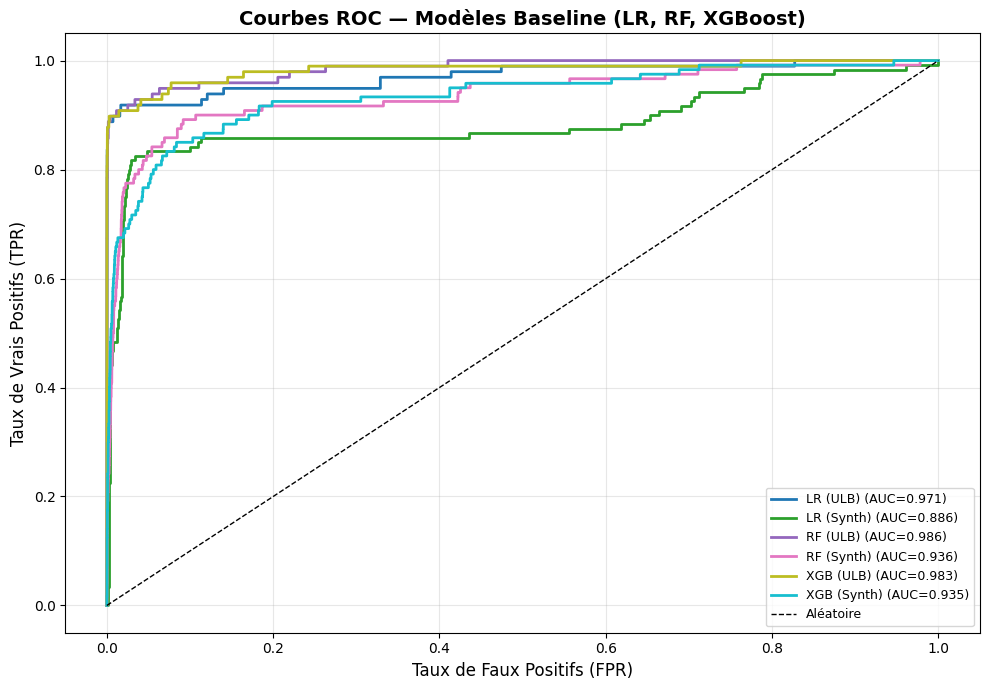

In [10]:
if results:
    results_df = pd.DataFrame(results)
    print("\n📊 TABLEAU COMPARATIF DES MODÈLES BASELINE")
    print("=" * 75)
    display(results_df.sort_values('F1', ascending=False).style
            .highlight_max(subset=['F1','AUC','Rappel'], color='#c8e6c9')
            .highlight_min(subset=['F1','AUC'], color='#ffcdd2')
            .format({col: '{:.4f}' for col in ['Précision','Rappel','F1','AUC','AUPRC']})
            .set_caption("Modèles Baseline — Comparaison (meilleur seuil par modèle)"))

    # Courbes ROC
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(roc_data)))
    for (name, (y_true, y_prob)), color in zip(roc_data.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=1, label='Aléatoire')
    ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
    ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
    ax.set_title('Courbes ROC — Modèles Baseline (LR, RF, XGBoost)', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## ✅ Résumé
- Logistic Regression : modèle de référence (baseline littérature)
- Random Forest : excellent sur données tabulaires déséquilibrées
- XGBoost : meilleure performance générale sur ULB
- Évaluation sur **deux datasets** validée